## 1. Imports and numerical settings

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scqubits as scq
from scipy.linalg import cosm


# Output path
FIGURE_FOLDER = Path("figures")
FIGURE_FOLDER.mkdir(exist_ok=True)

# Circuit-energy parameters in GHz.
EJ = 8.9
EC = 2.5
EL = 0.5

# Convergence settings used throughout the analysis.
N_REF = 200
CUTOFF_VALUES = np.arange(10, 101, 2)
TOLERANCE_GHZ = 1e-3  # 1 MHz
# Shared flux grid and large-cutoff values used for reference validation.
CONVERGENCE_FLUX_VALUES = np.linspace(0, 2, 51)
REFERENCE_CUTOFFS = [150, 200, 250, 300]


## 2. Fluxonium Hamiltonian

In [2]:
def calculate_fluxonium_energies(
    EJ,
    EC,
    EL,
    cutoff,
    flux_fraction,
    truncated_dim,
):
    """Return the lowest fluxonium eigenenergies in a truncated oscillator basis."""
    # Convert reduced external flux Phi_ext/Phi_0 to phase.
    phi_ext = 2 * np.pi * flux_fraction
    # Harmonic LC spacing and zero-point phase fluctuation.
    f_lc = np.sqrt(8 * EC * EL)
    phi_zpf = (2 * EC / EL) ** 0.25

    oscillator_levels = np.arange(cutoff)
    H0 = np.diag(f_lc * (oscillator_levels + 0.5))

    # Construct phi = phi_zpf(a + a^dagger) in the truncated basis.
    off_diagonal = phi_zpf * np.sqrt(np.arange(1, cutoff))
    phi_op = (
        np.diag(off_diagonal, k=1)
        + np.diag(off_diagonal, k=-1)
    )

    # Evaluate the Josephson cosine as a matrix function.
    junction_phase_op = phi_op - phi_ext * np.eye(cutoff)
    H = H0 - EJ * cosm(junction_phase_op)

    energies = np.linalg.eigvalsh(H)
    return energies[:truncated_dim]

## 3. Fluxonium potential

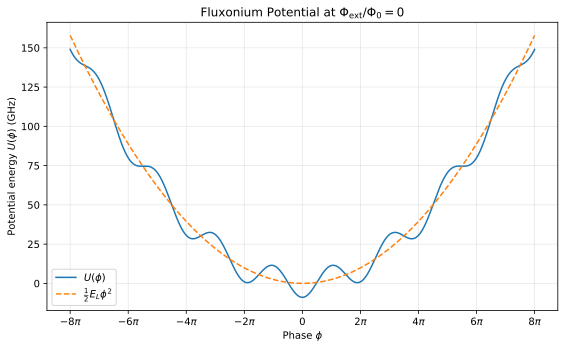

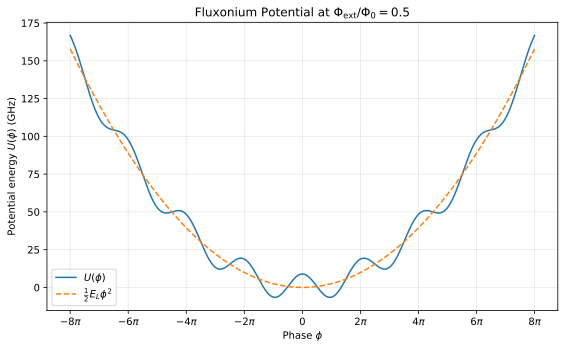

In [3]:
def plot_fluxonium_potential(flux_fraction, filename):
    """Plot the fluxonium potential and its harmonic contribution."""
    phi = np.linspace(-8 * np.pi, 8 * np.pi, 2000)
    phi_ext = 2 * np.pi * flux_fraction

    # Fluxonium potential in the same convention used by the Hamiltonian.
    harmonic_potential = 0.5 * EL * phi**2
    fluxonium_potential = (
        harmonic_potential
        - EJ * np.cos(phi - phi_ext)
    )

    plt.figure(figsize=(8, 5))
    plt.plot(
        phi,
        fluxonium_potential,
        label=r"$U(\phi)$",
    )
    plt.plot(
        phi,
        harmonic_potential,
        linestyle="--",
        label=r"$\frac{1}{2}E_L\phi^2$",
    )

    tick_multiples = np.arange(-8, 9, 2)
    tick_positions = tick_multiples * np.pi
    tick_labels = [
        rf"${n}\pi$" if n != 0 else r"$0$"
        for n in tick_multiples
    ]

    plt.xticks(tick_positions, tick_labels)
    plt.xlabel(r"Phase $\phi$")
    plt.ylabel(r"Potential energy $U(\phi)$ (GHz)")
    plt.title(
        rf"Fluxonium Potential at "
        rf"$\Phi_{{\mathrm{{ext}}}}/\Phi_0 = {flux_fraction:g}$"
    )
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        FIGURE_FOLDER / filename,
        bbox_inches="tight",
    )
    plt.show()


plot_fluxonium_potential(
    flux_fraction=0.0,
    filename="potential_zero_flux.pdf",
)

plot_fluxonium_potential(
    flux_fraction=0.5,
    filename="potential_half_flux.pdf",
)

## 4. Convergence utilities

In [4]:
def calculate_relative_energy(
    EJ,
    EC,
    EL,
    cutoff,
    flux_fraction,
    state,
):
    """Return E_state - E_0 for one basis cutoff and external flux."""
    energies = calculate_fluxonium_energies(
        EJ,
        EC,
        EL,
        cutoff,
        flux_fraction,
        truncated_dim=state + 1,
    )
    return energies[state] - energies[0]


def calculate_state_convergence_errors(
    EJ,
    EC,
    EL,
    flux_fraction,
    cutoff_values,
    N_ref,
    state,
):
    """Compare a relative energy with the value obtained at the reference cutoff."""
    # Use the large-cutoff result as the numerical reference.
    reference_energy = calculate_relative_energy(
        EJ,
        EC,
        EL,
        N_ref,
        flux_fraction,
        state,
    )

    errors = []
    for cutoff in cutoff_values:
        energy = calculate_relative_energy(
            EJ,
            EC,
            EL,
            cutoff,
            flux_fraction,
            state,
        )
        errors.append(abs(energy - reference_energy))

    return np.array(errors)


def calculate_state_minimum_cutoff(
    EJ,
    EC,
    EL,
    flux_fraction,
    cutoff_values,
    N_ref,
    tolerance,
    state,
):
    """Return the first cutoff after which all tested errors remain below tolerance."""
    errors = calculate_state_convergence_errors(
        EJ,
        EC,
        EL,
        flux_fraction,
        cutoff_values,
        N_ref,
        state,
    )

    # Require persistent convergence: every larger tested cutoff must
    # remain below the tolerance, not just the first crossing.
    for i, cutoff in enumerate(cutoff_values):
        if np.all(errors[i:] < tolerance):
            return cutoff

    return None

## 5. Reference-cutoff validation

Verify that $N_{\mathrm{ref}}=200$ is already numerically stable over the same external-flux range and the first four relative eigenenergies used in the convergence conclusions.


In [ ]:
# Reference-validation grid and cutoffs.
CONVERGENCE_FLUX_VALUES = np.linspace(0, 2, 51)
REFERENCE_CUTOFFS = [150, 200, 250, 300]

reference_states = [1, 2, 3, 4]

# Recalculate the first four relative eigenenergies at several large cutoffs
# over the same 51-point flux sweep used in the convergence analysis.
reference_validation = {}

for cutoff in REFERENCE_CUTOFFS:
    relative_spectra = np.zeros(
        (len(CONVERGENCE_FLUX_VALUES), max(reference_states) + 1)
    )

    for j, flux_fraction in enumerate(CONVERGENCE_FLUX_VALUES):
        energies = calculate_fluxonium_energies(
            EJ,
            EC,
            EL,
            cutoff,
            flux_fraction,
            truncated_dim=max(reference_states) + 1,
        )
        relative_spectra[j] = energies - energies[0]

    reference_validation[cutoff] = relative_spectra

print("Maximum difference over f in [0, 2] and states E1-E0 through E4-E0")
print("------------------------------------------------------------------")

for lower, upper in zip(REFERENCE_CUTOFFS[:-1], REFERENCE_CUTOFFS[1:]):
    differences = np.abs(
        reference_validation[lower][:, 1:5]
        - reference_validation[upper][:, 1:5]
    )

    flat_index = np.argmax(differences)
    flux_index, state_index = np.unravel_index(
        flat_index,
        differences.shape,
    )

    max_difference = differences[flux_index, state_index]
    flux_at_max = CONVERGENCE_FLUX_VALUES[flux_index]
    state_at_max = reference_states[state_index]

    print(
        f"N={lower:3d} -> {upper:3d}: "
        f"{max_difference:.3e} GHz "
        f"(E{state_at_max}-E0 at f={flux_at_max:.2f})"
    )


## 6. Figure 3 — convergence versus basis cutoff

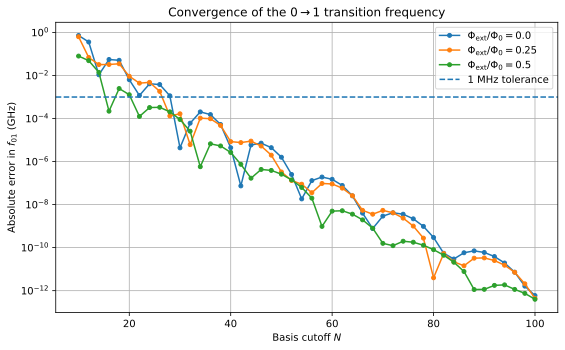

In [5]:
# Representative flux biases used to compare cutoff convergence.
representative_fluxes = [0.0, 0.25, 0.5]

plt.figure(figsize=(8, 5))

for flux_fraction in representative_fluxes:
    errors = calculate_state_convergence_errors(
        EJ,
        EC,
        EL,
        flux_fraction,
        CUTOFF_VALUES,
        N_REF,
        state=1,
    )

    plt.semilogy(
        CUTOFF_VALUES,
        errors,
        marker="o",
        markersize=4,
        label=rf"$\Phi_{{\mathrm{{ext}}}}/\Phi_0={flux_fraction}$",
    )

# Show the 1 MHz convergence threshold used in the paper.
plt.axhline(
    TOLERANCE_GHZ,
    linestyle="--",
    label="1 MHz tolerance",
)

plt.xlabel(r"Basis cutoff $N$")
plt.ylabel(r"Absolute error in $f_{01}$ (GHz)")
plt.title(r"Convergence of the $0\rightarrow1$ transition frequency")
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig(
    FIGURE_FOLDER / "convergence_vs_cutoff.pdf",
    bbox_inches="tight",
)
plt.show()

## 7. Figure 4 — basis-truncation error across external flux

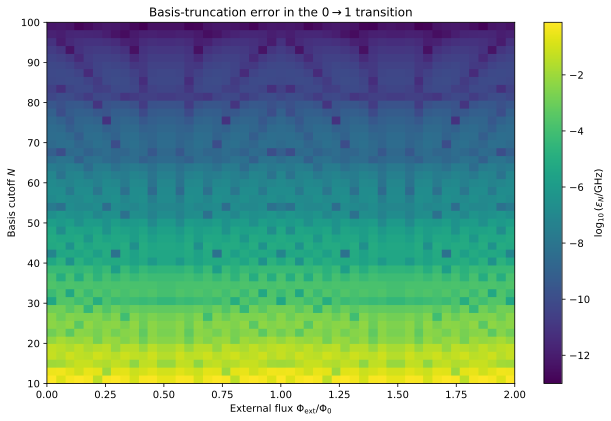

In [6]:
# Sweep two flux periods to test convergence across external flux.
convergence_flux_values = CONVERGENCE_FLUX_VALUES

error_matrix = np.zeros(
    (len(CUTOFF_VALUES), len(convergence_flux_values))
)

for j, flux_fraction in enumerate(convergence_flux_values):
    error_matrix[:, j] = calculate_state_convergence_errors(
        EJ,
        EC,
        EL,
        flux_fraction,
        CUTOFF_VALUES,
        N_REF,
        state=1,
    )

# Apply a numerical floor before taking log10 so zero roundoff values
# do not produce -inf in the heatmap.
safe_error_matrix = np.maximum(error_matrix, 1e-15)
log_error_matrix = np.log10(safe_error_matrix)

plt.figure(figsize=(9, 6))

image = plt.imshow(
    log_error_matrix,
    origin="lower",
    aspect="auto",
    extent=[
        convergence_flux_values[0],
        convergence_flux_values[-1],
        CUTOFF_VALUES[0],
        CUTOFF_VALUES[-1],
    ],
)

cbar = plt.colorbar(image)
cbar.set_label(r"$\log_{10}(\epsilon_N/\mathrm{GHz})$")

plt.xlabel(r"External flux $\Phi_{\mathrm{ext}}/\Phi_0$")
plt.ylabel(r"Basis cutoff $N$")
plt.title(r"Basis-truncation error in the $0\rightarrow1$ transition")
plt.tight_layout()

plt.savefig(
    FIGURE_FOLDER / "convergence_error_heatmap.pdf",
    bbox_inches="tight",
)
plt.show()

## 8. Figure 5 — state-dependent convergence

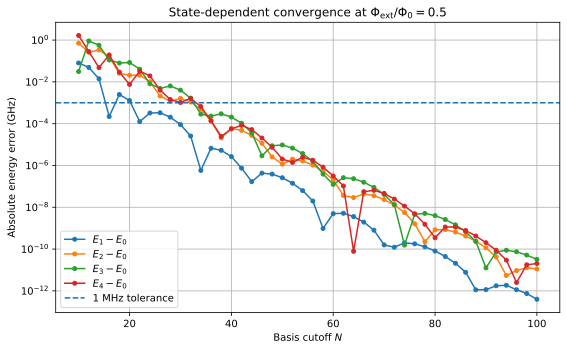

In [7]:
# Compare convergence of higher relative eigenenergies at half flux.
flux_fraction = 0.5
states = [1, 2, 3, 4]

plt.figure(figsize=(8, 5))

for state in states:
    errors = calculate_state_convergence_errors(
        EJ,
        EC,
        EL,
        flux_fraction,
        CUTOFF_VALUES,
        N_REF,
        state,
    )

    plt.semilogy(
        CUTOFF_VALUES,
        errors,
        marker="o",
        markersize=4,
        label=rf"$E_{state}-E_0$",
    )

# Show the 1 MHz convergence threshold used in the paper.
plt.axhline(
    TOLERANCE_GHZ,
    linestyle="--",
    label="1 MHz tolerance",
)

plt.xlabel(r"Basis cutoff $N$")
plt.ylabel("Absolute energy error (GHz)")
plt.title(
    r"State-dependent convergence at "
    r"$\Phi_{\mathrm{ext}}/\Phi_0=0.5$"
)
plt.legend()
plt.grid()
plt.tight_layout()

plt.savefig(
    FIGURE_FOLDER / "state_convergence.pdf",
    bbox_inches="tight",
)
plt.show()

## 9. Harmonic-limit validation

In [8]:
# Setting EJ = 0 removes the Josephson term and gives the exactly
# solvable harmonic-oscillator limit.
cutoff_test = 40
num_levels = 6
flux_test = 0.0
EJ_test = 0.0

energies_num = calculate_fluxonium_energies(
    EJ_test,
    EC,
    EL,
    cutoff_test,
    flux_test,
    num_levels,
)
energies_num_rel = energies_num - energies_num[0]

k = np.arange(num_levels)
energies_exact = k * np.sqrt(8 * EC * EL)
errors = np.abs(energies_num_rel - energies_exact)

print("k    Numerical (GHz)    Analytical (GHz)    Error (GHz)")
for i in range(num_levels):
    print(
        f"{i:<4}"
        f"{energies_num_rel[i]:<19.10f}"
        f"{energies_exact[i]:<20.10f}"
        f"{errors[i]:.3e}"
    )

k    Numerical (GHz)    Analytical (GHz)    Error (GHz)
0   0.0000000000       0.0000000000        0.000e+00
1   3.1622776602       3.1622776602        4.441e-16
2   6.3245553203       6.3245553203        0.000e+00
3   9.4868329805       9.4868329805        1.776e-15
4   12.6491106407      12.6491106407       0.000e+00
5   15.8113883008      15.8113883008       0.000e+00


## 10. Comparison with scqubits

In [ ]:
# Cross-check the custom matrix construction against scqubits using
# identical circuit parameters, flux values, and basis cutoff.
comparison_fluxes = [0.0, 0.25, 0.5]
cutoff_test = 40
num_levels = 5

print("flux    k    custom (GHz)    scqubits (GHz)    eta_k")

for flux_fraction in comparison_fluxes:
    custom = calculate_fluxonium_energies(
        EJ,
        EC,
        EL,
        cutoff_test,
        flux_fraction,
        num_levels,
    )
    custom = custom - custom[0]

    fluxonium = scq.Fluxonium(
        EJ=EJ,
        EC=EC,
        EL=EL,
        flux=flux_fraction,
        cutoff=cutoff_test,
    )
    scq_energies = fluxonium.eigenvals(evals_count=num_levels)
    scq_energies = scq_energies - scq_energies[0]

    transition_scale = scq_energies[1]

    for k in range(1, num_levels):
        eta_k = abs(custom[k] - scq_energies[k]) / transition_scale
        print(
            f"{flux_fraction:4.2f}    "
            f"{k}    "
            f"{custom[k]:.10f}    "
            f"{scq_energies[k]:.10f}    "
            f"{eta_k:.3e}"
        )


## 11. Low-lying energy spectrum

In [ ]:
cutoff = 40
num_levels = 6
spectrum_flux_values = np.linspace(0, 1, 201)

# Subtract E0 at each flux so the spectrum is shown in relative energies.
relative_energies = []

for flux_fraction in spectrum_flux_values:
    energies = calculate_fluxonium_energies(
        EJ,
        EC,
        EL,
        cutoff,
        flux_fraction,
        num_levels,
    )
    relative_energies.append(energies - energies[0])

relative_energies = np.array(relative_energies)

plt.figure(figsize=(8, 5.5))

for k in range(num_levels):
    plt.plot(
        spectrum_flux_values,
        relative_energies[:, k],
        label=fr"$E_{k}-E_0$",
    )

plt.xlabel(r"External flux $\Phi_{\mathrm{ext}}/\Phi_0$")
plt.ylabel(r"Relative energy $(E_k-E_0)/h$ (GHz)")
plt.title("Lowest fluxonium energy levels")
plt.xlim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_FOLDER / "fluxonium_spectrum.pdf",
    bbox_inches="tight",
)
plt.show()

## 12. Figure 6 — required cutoff across flux and state

In [11]:
states = [1, 2, 3, 4]

# Store the minimum persistently converged cutoff for each flux and state.
minimum_cutoff_matrix = np.full(
    (len(convergence_flux_values), len(states)),
    np.nan,
)

for j, flux_fraction in enumerate(convergence_flux_values):
    print(
        f"Calculating flux {j + 1}/{len(convergence_flux_values)}: "
        f"{flux_fraction:.2f}"
    )

    # Compute the reference spectrum once for each external-flux value.
    reference_energies = calculate_fluxonium_energies(
        EJ,
        EC,
        EL,
        N_REF,
        flux_fraction,
        truncated_dim=max(states) + 1,
    )
    reference_relative = reference_energies - reference_energies[0]

    state_errors = np.zeros((len(CUTOFF_VALUES), len(states)))

    for i, cutoff in enumerate(CUTOFF_VALUES):
        energies = calculate_fluxonium_energies(
            EJ,
            EC,
            EL,
            cutoff,
            flux_fraction,
            truncated_dim=max(states) + 1,
        )
        relative = energies - energies[0]

        for s, state in enumerate(states):
            state_errors[i, s] = abs(
                relative[state] - reference_relative[state]
            )

    # Apply the same persistent-convergence criterion to every state.
    for s in range(len(states)):
        for i, cutoff in enumerate(CUTOFF_VALUES):
            if np.all(state_errors[i:, s] < TOLERANCE_GHZ):
                minimum_cutoff_matrix[j, s] = cutoff
                break

Calculating flux 1/51: 0.00
Calculating flux 2/51: 0.04
Calculating flux 3/51: 0.08
Calculating flux 4/51: 0.12
Calculating flux 5/51: 0.16
Calculating flux 6/51: 0.20
Calculating flux 7/51: 0.24
Calculating flux 8/51: 0.28
Calculating flux 9/51: 0.32
Calculating flux 10/51: 0.36
Calculating flux 11/51: 0.40
Calculating flux 12/51: 0.44
Calculating flux 13/51: 0.48
Calculating flux 14/51: 0.52
Calculating flux 15/51: 0.56
Calculating flux 16/51: 0.60
Calculating flux 17/51: 0.64
Calculating flux 18/51: 0.68
Calculating flux 19/51: 0.72
Calculating flux 20/51: 0.76
Calculating flux 21/51: 0.80
Calculating flux 22/51: 0.84
Calculating flux 23/51: 0.88
Calculating flux 24/51: 0.92
Calculating flux 25/51: 0.96
Calculating flux 26/51: 1.00
Calculating flux 27/51: 1.04
Calculating flux 28/51: 1.08
Calculating flux 29/51: 1.12
Calculating flux 30/51: 1.16
Calculating flux 31/51: 1.20
Calculating flux 32/51: 1.24
Calculating flux 33/51: 1.28
Calculating flux 34/51: 1.32
Calculating flux 35/51:

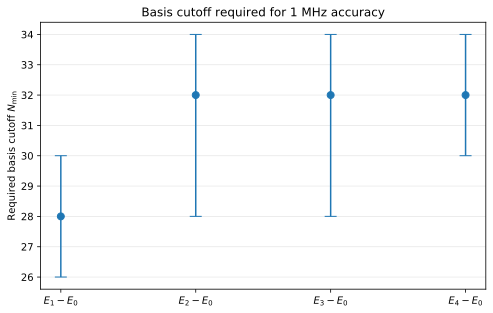

In [12]:
state_labels = [
    r"$E_1-E_0$",
    r"$E_2-E_0$",
    r"$E_3-E_0$",
    r"$E_4-E_0$",
]

# Summarize how the required cutoff varies across the tested flux range.
medians = np.nanmedian(minimum_cutoff_matrix, axis=0)
minimums = np.nanmin(minimum_cutoff_matrix, axis=0)
maximums = np.nanmax(minimum_cutoff_matrix, axis=0)

yerr = np.vstack([
    medians - minimums,
    maximums - medians,
])

x = np.arange(len(states))

plt.figure(figsize=(7, 4.5))
plt.errorbar(
    x,
    medians,
    yerr=yerr,
    fmt="o",
    capsize=6,
    markersize=7,
)

plt.xticks(x, state_labels)
plt.ylabel(r"Required basis cutoff $N_{\min}$")
plt.title(r"Basis cutoff required for $1$ MHz accuracy")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    FIGURE_FOLDER / "minimum_cutoff_summary.pdf",
    bbox_inches="tight",
)
plt.show()

## 13. Compact convergence summary

In [13]:
print("State    Maximum required N    Flux where maximum first occurs")
print("--------------------------------------------------------------")

# Report the worst-case required cutoff for each tested relative energy.
state_maximum_cutoffs = []

for s, state in enumerate(states):
    values = minimum_cutoff_matrix[:, s]

    if np.all(np.isnan(values)):
        print(f"E{state}-E0    Not converged within tested range")
        continue

    maximum_N = int(np.nanmax(values))
    first_index = np.where(values == maximum_N)[0][0]
    first_flux = convergence_flux_values[first_index]

    state_maximum_cutoffs.append(maximum_N)

    print(
        f"E{state}-E0"
        f"        {maximum_N:<20}"
        f"{first_flux:.2f}"
    )

if state_maximum_cutoffs:
    overall_cutoff = max(state_maximum_cutoffs)
    print(
        "\nConservative cutoff for all tested states and flux values:"
    )
    print(f"N = {overall_cutoff}")

State    Maximum required N    Flux where maximum first occurs
--------------------------------------------------------------
E1-E0        30                  0.00
E2-E0        34                  0.16
E3-E0        34                  0.00
E4-E0        34                  0.16

Conservative cutoff for all tested states and flux values:
N = 34
